In [55]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("EDA libraries imported successfully!")

EDA libraries imported successfully!


In [56]:
# Load the cleaned Kickstarter dataset

df = pd.read_csv("../data/processed/kickstarter_cleaned.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)

Cleaned dataset loaded successfully!
Shape: (331672, 11)


In [57]:
# Analyze target distribution

target_counts = df["target"].value_counts()

print("Target distribution:")
print(target_counts)

print("\nTarget percentages:")
print((target_counts / len(df) * 100).round(2))


Target distribution:
target
0    197716
1    133956
Name: count, dtype: int64

Target percentages:
target
0    59.61
1    40.39
Name: count, dtype: float64


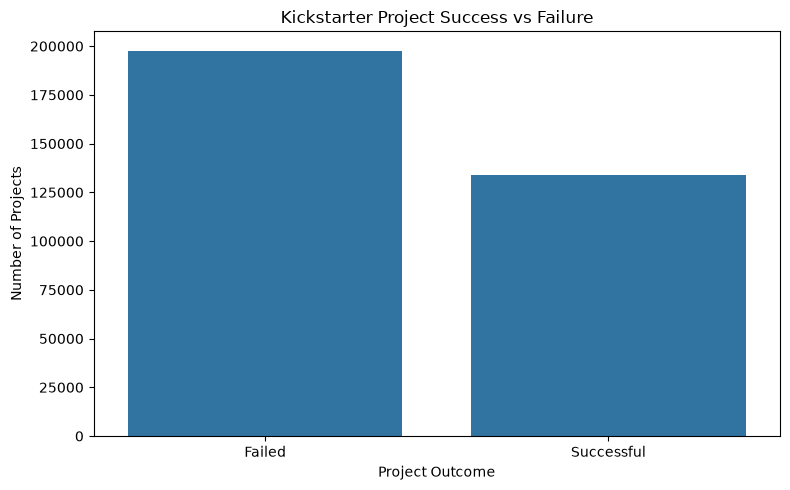

In [58]:
# Plot 1: Successful vs Failed Kickstarter Projects

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Kickstarter Project Success vs Failure")
plt.xlabel("Project Outcome")
plt.ylabel("Number of Projects")

plt.xticks(
    [0, 1],
    ["Failed", "Successful"]
)

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/target_distribution.png", dpi=300)

plt.show()

In [59]:
# Calculate success rate by main category

category_success = (
    df.groupby("main_category")["target"]
      .mean()
      .sort_values(ascending=False)
)

print("Success rate by main category:")
print((category_success * 100).round(2))

Success rate by main category:
main_category
Dance           65.44
Theater         63.80
Comics          59.14
Music           52.66
Art             44.89
Games           43.89
Film & Video    41.79
Design          41.59
Publishing      34.70
Photography     34.11
Fashion         28.28
Food            27.59
Crafts          27.05
Journalism      24.39
Technology      23.79
Name: target, dtype: float64


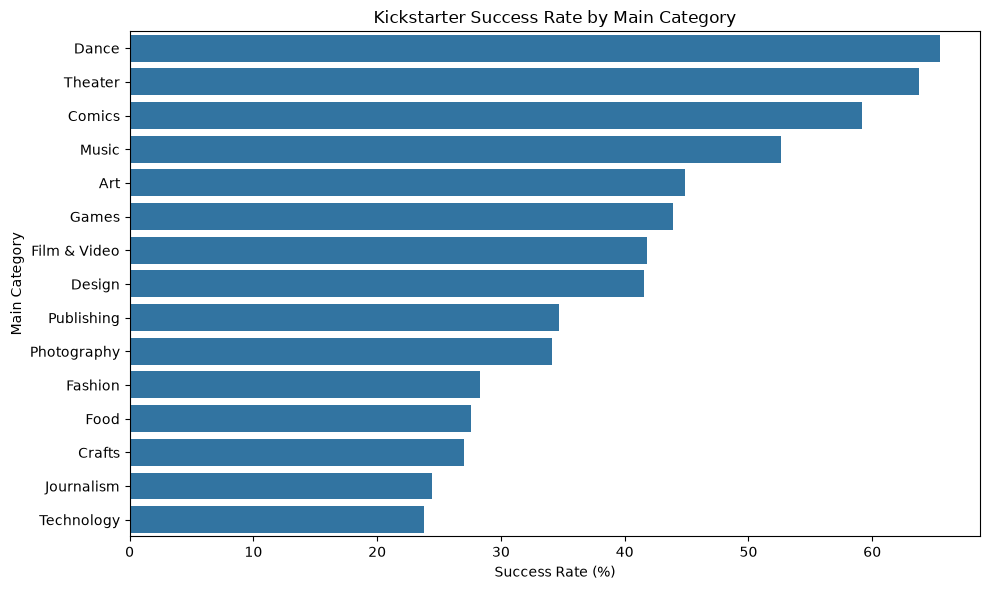

In [60]:
# Plot 2: Success rate by main category

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_success.values * 100,
    y=category_success.index
)

plt.title("Kickstarter Success Rate by Main Category")
plt.xlabel("Success Rate (%)")
plt.ylabel("Main Category")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/success_rate_by_category.png", dpi=300)

plt.show()

In [61]:
# Analyze goal amount by project outcome

goal_stats = (
    df.groupby("target")["usd_goal_real"]
      .agg(["count", "mean", "median", "min", "max"])
)

print("Goal amount statistics by project outcome:")
print(goal_stats)

Goal amount statistics by project outcome:
         count          mean   median   min           max
target                                                   
0       197716  63174.495905  7500.00  0.15  1.663614e+08
1       133956   9532.853357  3837.74  0.01  2.015609e+06


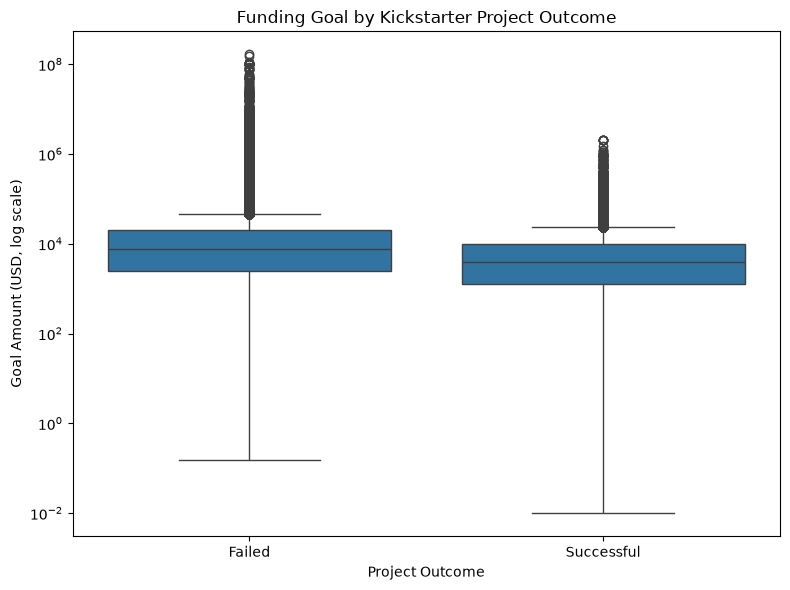

In [62]:
# Plot 3: Goal amount by project outcome

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="target",
    y="usd_goal_real"
)

plt.yscale("log")

plt.title("Funding Goal by Kickstarter Project Outcome")
plt.xlabel("Project Outcome")
plt.ylabel("Goal Amount (USD, log scale)")

plt.xticks(
    [0, 1],
    ["Failed", "Successful"]
)

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/goal_by_outcome.png", dpi=300)

plt.show()

In [63]:
# Analyze campaign duration by project outcome

duration_stats = (
    df.groupby("target")["duration_days"]
      .agg(["count", "mean", "median", "min", "max"])
)

print("Campaign duration statistics by project outcome:")
print(duration_stats)

Campaign duration statistics by project outcome:
         count       mean     median       min        max
target                                                   
0       197716  34.610378  29.736736  0.035498  91.962650
1       133956  31.587186  29.466476  0.005058  91.680648


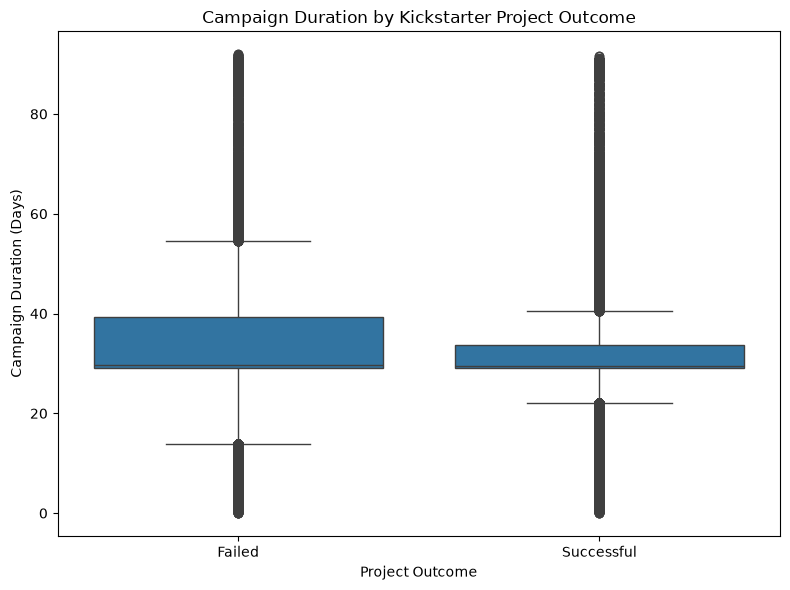

In [64]:
# Plot 4: Campaign duration by project outcome

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="target",
    y="duration_days"
)

plt.title("Campaign Duration by Kickstarter Project Outcome")
plt.xlabel("Project Outcome")
plt.ylabel("Campaign Duration (Days)")

plt.xticks(
    [0, 1],
    ["Failed", "Successful"]
)

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/duration_by_outcome.png", dpi=300)

plt.show()

In [65]:
# Calculate success rate by country

country_success = (
    df.groupby("country")["target"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

# Keep countries with at least 500 projects
country_success_filtered = country_success[country_success["count"] >= 500]

print("Countries with at least 500 projects:")
print((country_success_filtered["mean"] * 100).round(2))

Countries with at least 500 projects:
country
US    41.82
GB    40.97
DK    38.88
FR    36.03
NZ    35.16
SE    33.73
CA    33.42
AU    30.38
IE    30.31
BE    29.06
CH    28.68
MX    28.07
NO    27.84
DE    27.27
ES    26.27
NL    25.59
IT    18.53
Name: mean, dtype: float64


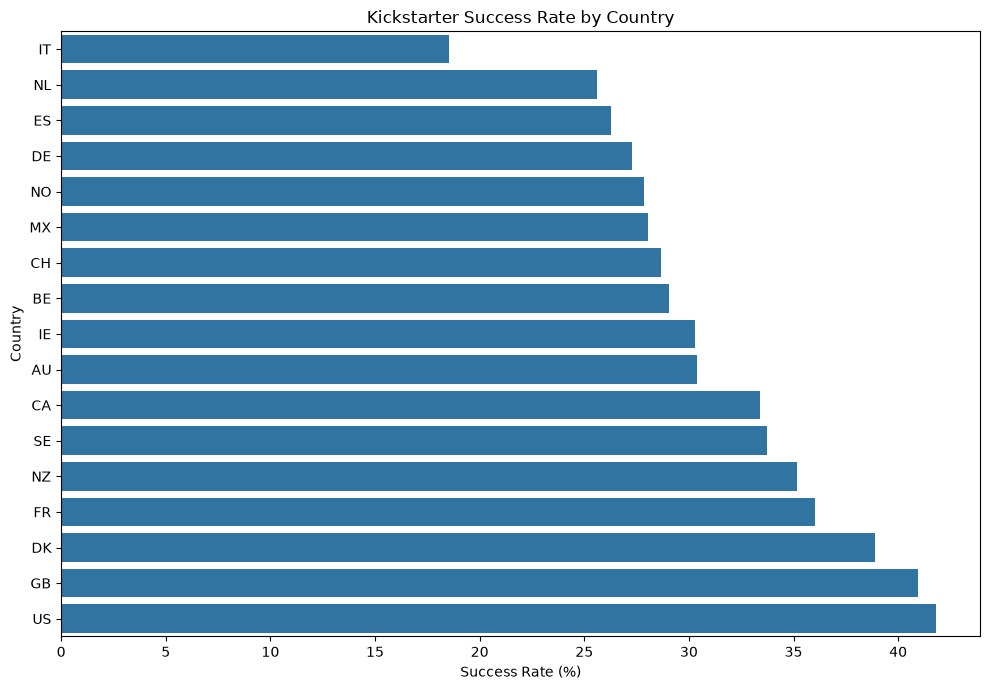

In [66]:
# Plot 5: Success rate by country

country_plot = country_success_filtered["mean"].sort_values(ascending=True) * 100

plt.figure(figsize=(10, 7))

sns.barplot(
    x=country_plot.values,
    y=country_plot.index
)

plt.title("Kickstarter Success Rate by Country")
plt.xlabel("Success Rate (%)")
plt.ylabel("Country")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/success_rate_by_country.png", dpi=300)

plt.show()

In [67]:
# Calculate success rate by currency

currency_success = (
    df.groupby("currency")["target"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

# Keep currencies with at least 500 projects
currency_success_filtered = currency_success[
    currency_success["count"] >= 500
]

print("Currencies with at least 500 projects:")
print((currency_success_filtered["mean"] * 100).round(2))

Currencies with at least 500 projects:
currency
USD    41.83
GBP    40.99
DKK    38.97
NZD    35.16
SEK    33.71
CAD    33.43
AUD    30.37
CHF    28.68
MXN    28.07
NOK    27.91
EUR    27.00
Name: mean, dtype: float64


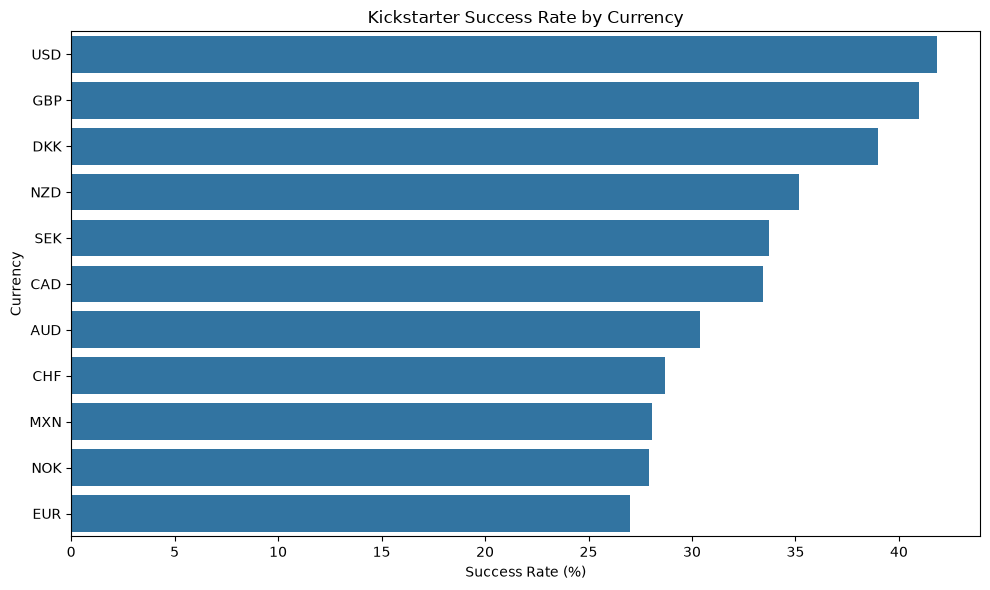

In [68]:
# Plot success rate by currency

plt.figure(figsize=(10, 6))

sns.barplot(
    x=currency_success_filtered["mean"].values * 100,
    y=currency_success_filtered.index
)

plt.title("Kickstarter Success Rate by Currency")
plt.xlabel("Success Rate (%)")
plt.ylabel("Currency")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/success_rate_by_currency.png", dpi=300)

plt.show()

In [69]:
# Analyze goal amount by project outcome

goal_stats = (
    df.groupby("target")["usd_goal_real"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("Goal amount statistics by project outcome:")
print(goal_stats)

Goal amount statistics by project outcome:
         count          mean   median   min           max
target                                                   
0       197716  63174.495905  7500.00  0.15  1.663614e+08
1       133956   9532.853357  3837.74  0.01  2.015609e+06


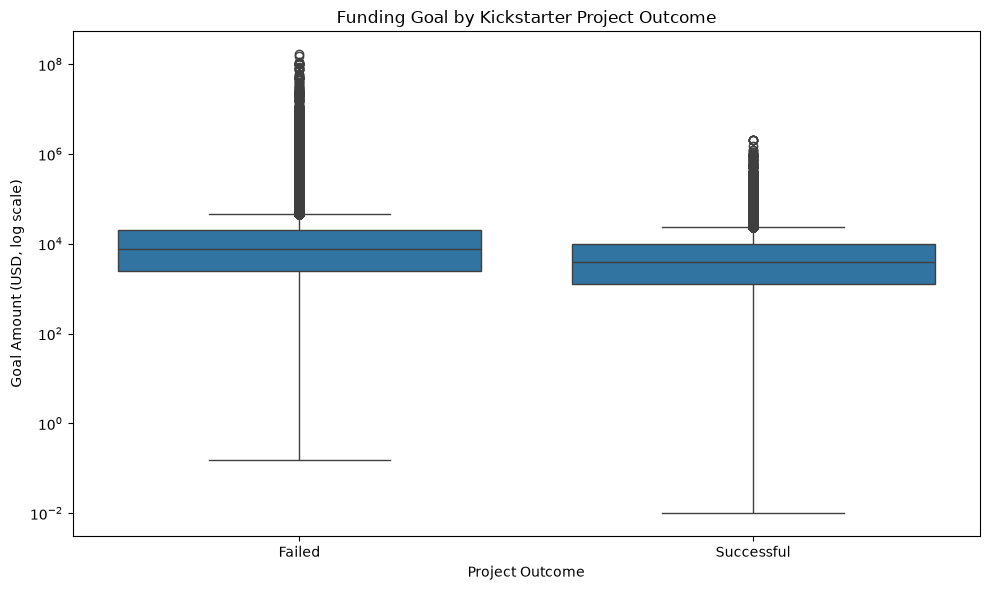

In [70]:
# Plot funding goal by project outcome

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df["target"].map({0: "Failed", 1: "Successful"}),
    y=df["usd_goal_real"]
)

plt.yscale("log")

plt.title("Funding Goal by Kickstarter Project Outcome")
plt.xlabel("Project Outcome")
plt.ylabel("Goal Amount (USD, log scale)")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/goal_by_outcome.png", dpi=300)

plt.show()

In [71]:
# Analyze campaign duration by project outcome

duration_stats = (
    df.groupby("target")["duration_days"]
    .agg(["count", "mean", "median", "min", "max"])
)

print("Campaign duration statistics by project outcome:")
print(duration_stats)

Campaign duration statistics by project outcome:
         count       mean     median       min        max
target                                                   
0       197716  34.610378  29.736736  0.035498  91.962650
1       133956  31.587186  29.466476  0.005058  91.680648


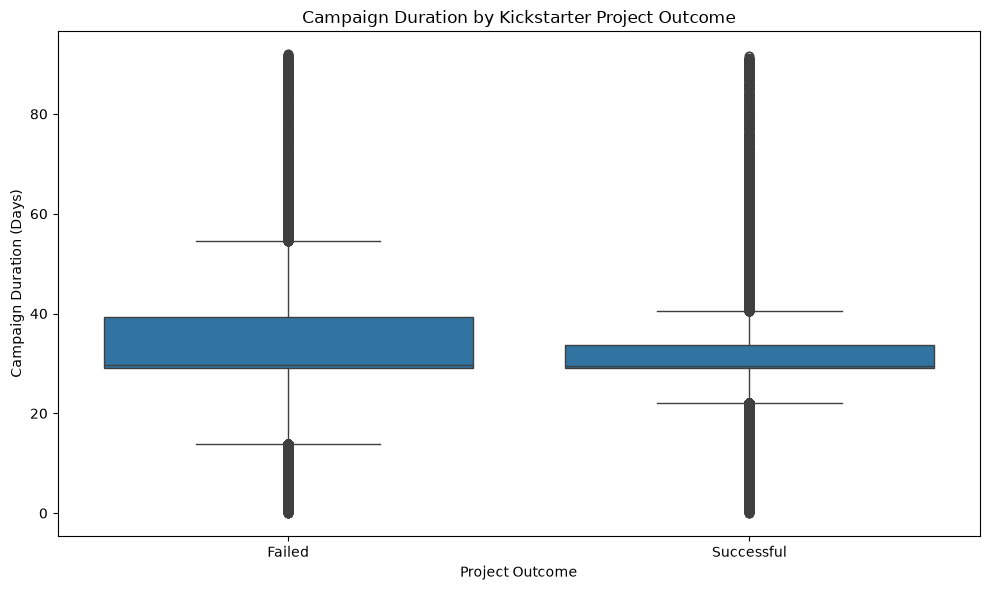

In [72]:
# Plot campaign duration by project outcome

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df["target"].map({0: "Failed", 1: "Successful"}),
    y=df["duration_days"]
)

plt.title("Campaign Duration by Kickstarter Project Outcome")
plt.xlabel("Project Outcome")
plt.ylabel("Campaign Duration (Days)")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/duration_by_outcome.png", dpi=300)

plt.show()

In [73]:
# Analyze relationship between goal amount and campaign duration

correlation = df[["usd_goal_real", "duration_days", "target"]].corr()

print("Correlation matrix:")
print(correlation.round(3))

Correlation matrix:
               usd_goal_real  duration_days  target
usd_goal_real          1.000          0.022  -0.024
duration_days          0.022          1.000  -0.117
target                -0.024         -0.117   1.000


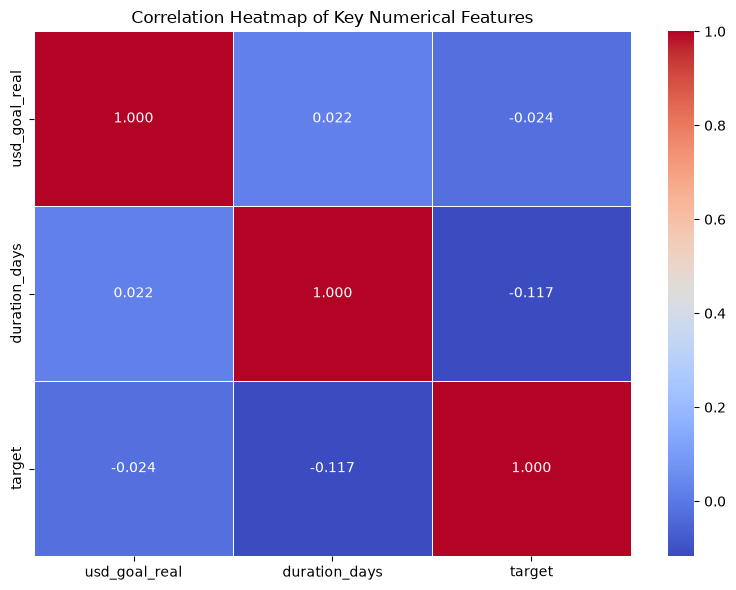

In [74]:
# Plot correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".3f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Key Numerical Features")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/correlation_heatmap.png", dpi=300)

plt.show()

In [75]:
# Analyze success rate by campaign duration range

df["duration_group"] = pd.cut(
    df["duration_days"],
    bins=[0, 15, 30, 45, 60, 92],
    labels=["0-15 days", "16-30 days", "31-45 days", "46-60 days", "61+ days"],
    include_lowest=True
)

duration_success = (
    df.groupby("duration_group", observed=True)["target"]
    .agg(["mean", "count"])
)

print("Success rate by campaign duration:")
print((duration_success["mean"] * 100).round(2))

Success rate by campaign duration:
duration_group
0-15 days     50.29
16-30 days    40.05
31-45 days    46.40
46-60 days    27.39
61+ days      38.74
Name: mean, dtype: float64


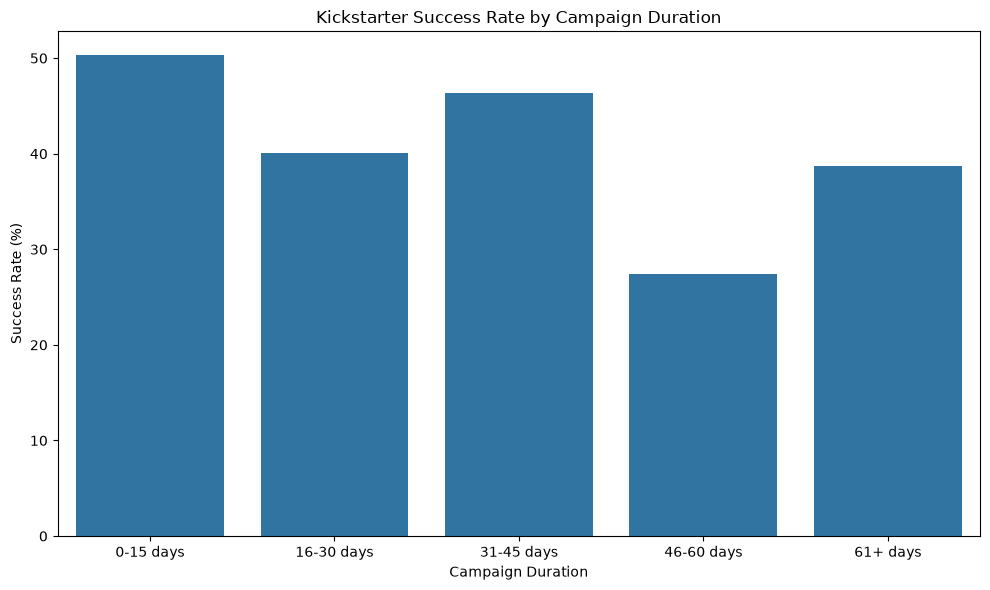

In [76]:
# Plot success rate by campaign duration range

plt.figure(figsize=(10, 6))

sns.barplot(
    x=duration_success.index,
    y=duration_success["mean"] * 100
)

plt.title("Kickstarter Success Rate by Campaign Duration")
plt.xlabel("Campaign Duration")
plt.ylabel("Success Rate (%)")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/success_rate_by_duration.png", dpi=300)

plt.show()

In [77]:
# Analyze success rate by funding goal range

df["goal_group"] = pd.cut(
    df["usd_goal_real"],
    bins=[0, 1000, 5000, 10000, 50000, float("inf")],
    labels=[
        "Under $1K",
        "$1K-$5K",
        "$5K-$10K",
        "$10K-$50K",
        "Above $50K"
    ],
    include_lowest=True
)

goal_success = (
    df.groupby("goal_group", observed=True)["target"]
    .agg(["mean", "count"])
)

print("Success rate by funding goal range:")
print((goal_success["mean"] * 100).round(2))

Success rate by funding goal range:
goal_group
Under $1K     53.80
$1K-$5K       46.61
$5K-$10K      39.46
$10K-$50K     31.05
Above $50K    13.08
Name: mean, dtype: float64


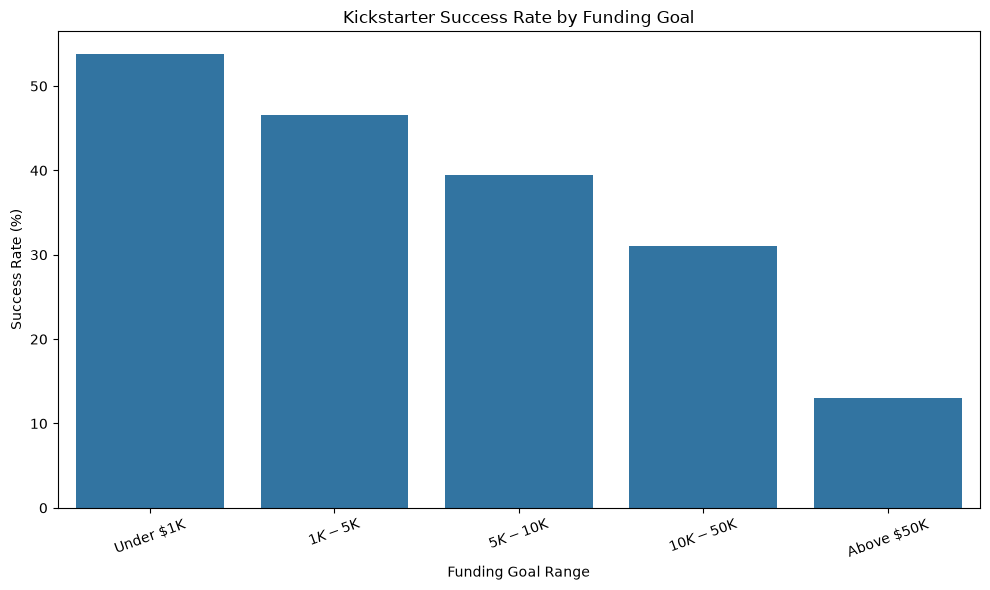

In [78]:
# Plot success rate by funding goal range

plt.figure(figsize=(10, 6))

sns.barplot(
    x=goal_success.index,
    y=goal_success["mean"] * 100
)

plt.title("Kickstarter Success Rate by Funding Goal")
plt.xlabel("Funding Goal Range")
plt.ylabel("Success Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/success_rate_by_goal.png", dpi=300)

plt.show()

In [79]:
# Analyze success rate by main category and funding goal range

category_goal_success = (
    df.groupby(["main_category", "goal_group"], observed=True)["target"]
    .mean()
    .unstack()
)

print("Success rate by main category and funding goal range:")
print((category_goal_success * 100).round(2))

Success rate by main category and funding goal range:
goal_group     Under $1K  $1K-$5K  $5K-$10K  $10K-$50K  Above $50K
main_category                                                     
Art                55.50    48.00     38.73      26.88        8.34
Comics             75.88    60.23     50.98      45.38       19.86
Crafts             41.42    22.01     18.22      13.37        2.41
Dance              68.42    71.15     63.07      45.43        3.70
Design             60.00    48.71     42.88      37.36       18.96
Fashion            37.63    26.61     28.44      27.38        6.10
Film & Video       55.08    49.78     43.22      33.95       13.47
Food               36.73    34.05     32.29      24.70        4.77
Games              61.18    50.98     43.55      35.70       19.16
Journalism         33.74    27.23     20.38      20.16        5.92
Music              58.27    56.55     52.55      40.67       11.22
Photography        45.29    33.07     28.41      32.27        8.04
Publishi

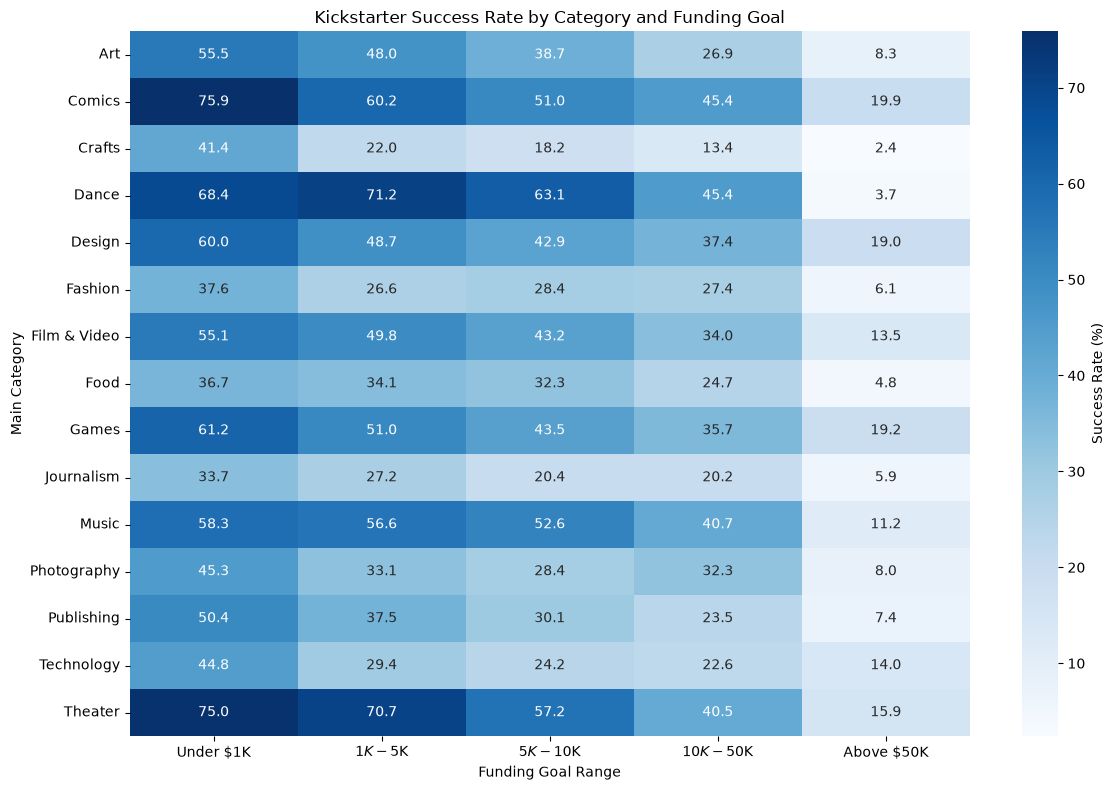

In [80]:
# Plot success rate by category and funding goal range

plt.figure(figsize=(12, 8))

sns.heatmap(
    category_goal_success * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Success Rate (%)"}
)

plt.title("Kickstarter Success Rate by Category and Funding Goal")
plt.xlabel("Funding Goal Range")
plt.ylabel("Main Category")

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/category_goal_success_heatmap.png", dpi=300)

plt.show()

In [81]:
# Analyze success rate by country and main category

country_category_success = (
    df.groupby(["country", "main_category"], observed=True)["target"]
    .agg(["mean", "count"])
)

# Keep combinations with at least 100 projects
country_category_filtered = country_category_success[
    country_category_success["count"] >= 100
]

print("Success rate by country and main category:")
print((country_category_filtered["mean"] * 100).round(2))

Success rate by country and main category:
country  main_category
AT       Technology       14.71
AU       Art              35.08
         Comics           58.43
         Crafts           23.87
         Design           41.74
                          ...  
US       Music            53.99
         Photography      35.15
         Publishing       34.75
         Technology       26.15
         Theater          63.72
Name: mean, Length: 130, dtype: float64


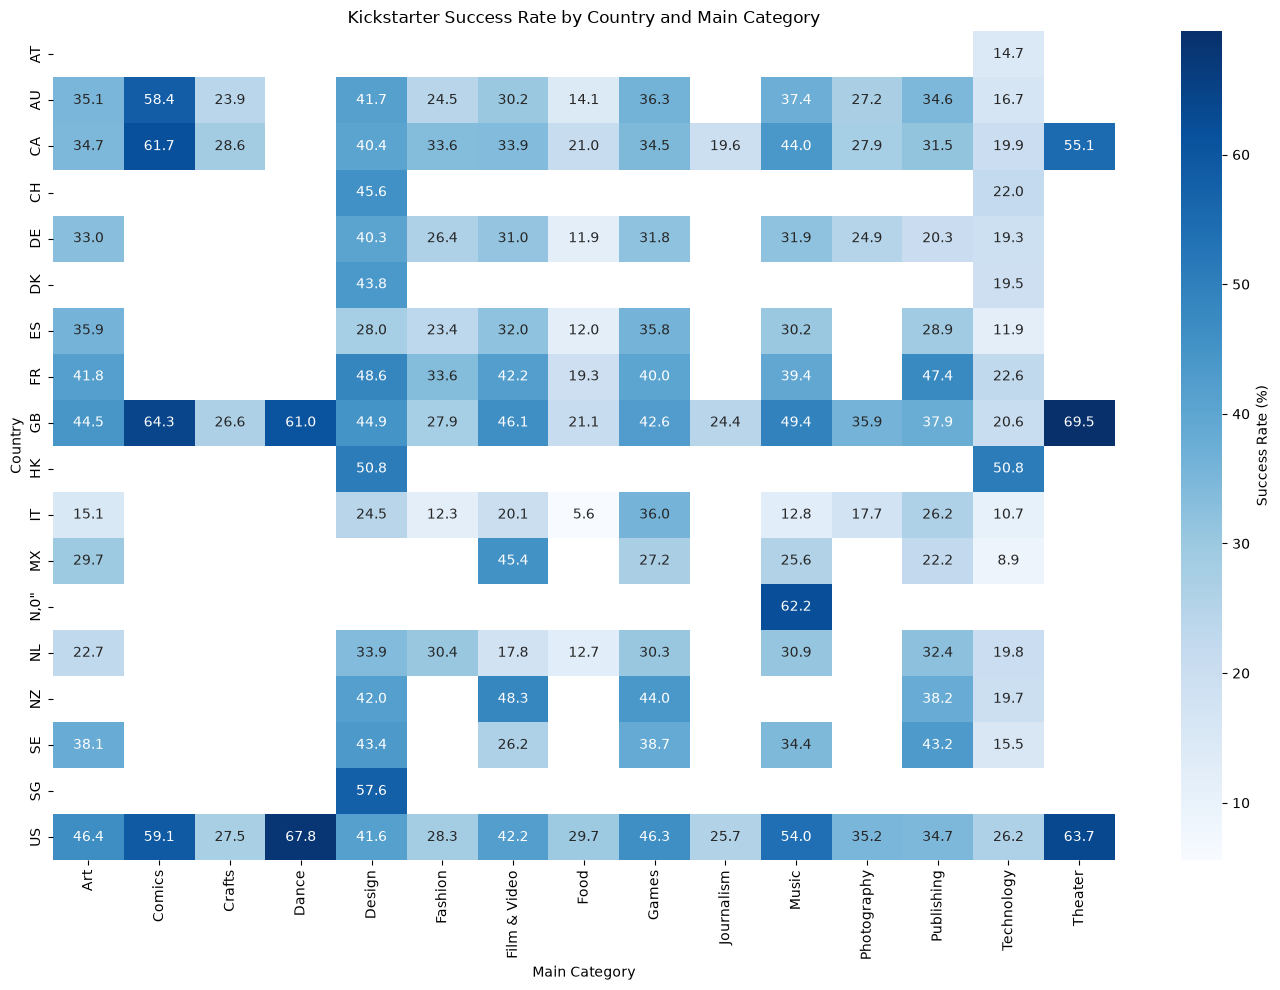

In [82]:
# Plot success rate by country and main category

country_category_pivot = (
    country_category_filtered["mean"]
    .unstack()
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    country_category_pivot * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Success Rate (%)"}
)

plt.title("Kickstarter Success Rate by Country and Main Category")
plt.xlabel("Main Category")
plt.ylabel("Country")

plt.tight_layout()

# Save the plot
plt.savefig(
    "../results/plots/country_category_success_heatmap.png",
    dpi=300
)

plt.show()

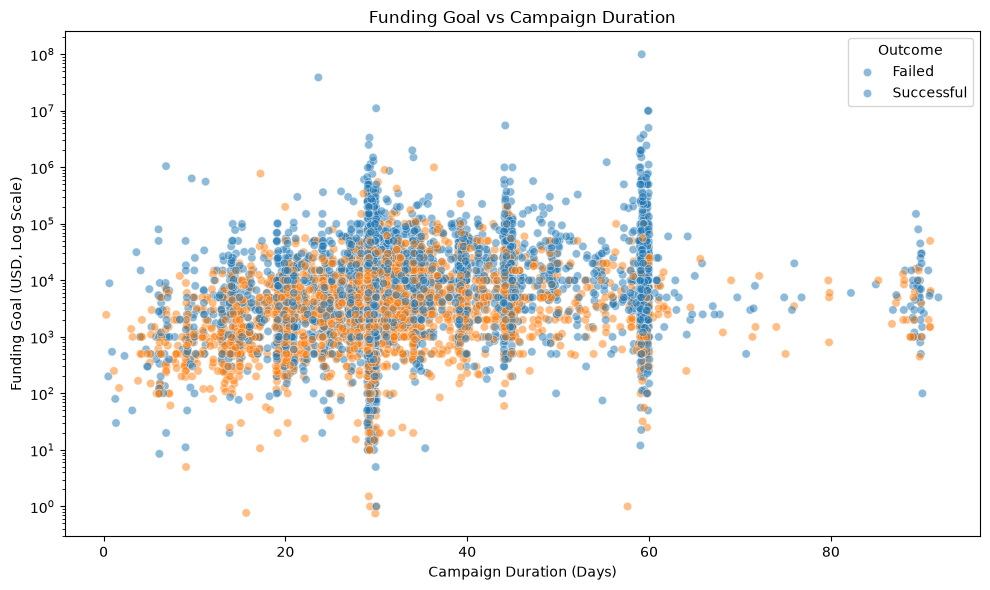

In [83]:
# Analyze relationship between funding goal and campaign duration

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="duration_days",
    y="usd_goal_real",
    hue="target",
    alpha=0.5
)

plt.yscale("log")

plt.title("Funding Goal vs Campaign Duration")
plt.xlabel("Campaign Duration (Days)")
plt.ylabel("Funding Goal (USD, Log Scale)")
plt.legend(title="Outcome", labels=["Failed", "Successful"])

plt.tight_layout()

# Save the plot
plt.savefig("../results/plots/goal_vs_duration.png", dpi=300)

plt.show()

In [84]:
# Check final columns and data types

print("Final columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Final columns:
['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'country', 'usd_goal_real', 'target', 'duration_days', 'duration_group', 'goal_group']

Data types:
name                   str
category               str
main_category          str
currency               str
deadline               str
goal               float64
launched               str
country                str
usd_goal_real      float64
target               int64
duration_days      float64
duration_group    category
goal_group        category
dtype: object


In [85]:
# Separate features and target

X = df.drop(columns=["target"]).copy()
y = df["target"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (331672, 12)
Target shape: (331672,)

Feature columns:
['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'country', 'usd_goal_real', 'duration_days', 'duration_group', 'goal_group']


In [86]:
# Remove EDA-only grouping columns

X = X.drop(columns=["duration_group", "goal_group"])

print("Features after removing EDA helper columns:")
print(X.columns.tolist())

print("\nNew feature shape:", X.shape)

Features after removing EDA helper columns:
['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'country', 'usd_goal_real', 'duration_days']

New feature shape: (331672, 10)


In [87]:
# Convert date columns to datetime

X["deadline"] = pd.to_datetime(X["deadline"])
X["launched"] = pd.to_datetime(X["launched"])

# Create date-based features
X["launch_year"] = X["launched"].dt.year
X["launch_month"] = X["launched"].dt.month
X["launch_day"] = X["launched"].dt.day
X["launch_weekday"] = X["launched"].dt.weekday

X["deadline_year"] = X["deadline"].dt.year
X["deadline_month"] = X["deadline"].dt.month
X["deadline_weekday"] = X["deadline"].dt.weekday

print("Date features created successfully!")

print("\nNew feature columns:")
print(X.columns.tolist())

Date features created successfully!

New feature columns:
['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'country', 'usd_goal_real', 'duration_days', 'launch_year', 'launch_month', 'launch_day', 'launch_weekday', 'deadline_year', 'deadline_month', 'deadline_weekday']


In [88]:
# Remove original date columns

X = X.drop(columns=["deadline", "launched"])

print("Original date columns removed successfully!")

print("\nCurrent feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)

Original date columns removed successfully!

Current feature columns:
['name', 'category', 'main_category', 'currency', 'goal', 'country', 'usd_goal_real', 'duration_days', 'launch_year', 'launch_month', 'launch_day', 'launch_weekday', 'deadline_year', 'deadline_month', 'deadline_weekday']

Feature shape: (331672, 15)


In [89]:
# Prepare categorical and numerical features

categorical_features = [
    "category",
    "main_category",
    "currency",
    "country"
]

numerical_features = [
    "goal",
    "usd_goal_real",
    "duration_days",
    "launch_year",
    "launch_month",
    "launch_day",
    "launch_weekday",
    "deadline_year",
    "deadline_month",
    "deadline_weekday"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['category', 'main_category', 'currency', 'country']

Numerical features:
['goal', 'usd_goal_real', 'duration_days', 'launch_year', 'launch_month', 'launch_day', 'launch_weekday', 'deadline_year', 'deadline_month', 'deadline_weekday']


In [90]:
# Create text-based features from project name

X["name_length"] = X["name"].str.len()
X["name_word_count"] = X["name"].str.split().str.len()

print("Text-based features created successfully!")

print("\nName feature statistics:")
print(X[["name_length", "name_word_count"]].describe())

Text-based features created successfully!

Name feature statistics:
         name_length  name_word_count
count  331672.000000    331672.000000
mean       34.220335         5.631027
std        15.961502         2.757329
min         1.000000         1.000000
25%        21.000000         3.000000
50%        33.000000         5.000000
75%        48.000000         8.000000
max        85.000000        29.000000


In [91]:
# Remove raw project name column

X = X.drop(columns=["name"])

print("Raw name column removed successfully!")

print("\nCurrent feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)

Raw name column removed successfully!

Current feature columns:
['category', 'main_category', 'currency', 'goal', 'country', 'usd_goal_real', 'duration_days', 'launch_year', 'launch_month', 'launch_day', 'launch_weekday', 'deadline_year', 'deadline_month', 'deadline_weekday', 'name_length', 'name_word_count']

Feature shape: (331672, 16)


In [92]:
# Encode categorical features using one-hot encoding

X_encoded = pd.get_dummies(
    X,
    columns=["category", "main_category", "currency", "country"],
    drop_first=True
)

print("Categorical features encoded successfully!")

print("\nEncoded feature shape:")
print(X_encoded.shape)

print("\nFirst 10 encoded columns:")
print(X_encoded.columns[:10].tolist())

Categorical features encoded successfully!

Encoded feature shape:
(331672, 219)

First 10 encoded columns:
['goal', 'usd_goal_real', 'duration_days', 'launch_year', 'launch_month', 'launch_day', 'launch_weekday', 'deadline_year', 'deadline_month', 'deadline_weekday']


In [93]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [94]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully!")

print("\nTraining features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Train-test split completed successfully!

Training features shape: (265337, 219)
Testing features shape: (66335, 219)

Training target shape: (265337,)
Testing target shape: (66335,)


In [95]:
# Train Logistic Regression model with more iterations

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [96]:
# Evaluate Logistic Regression model

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 61.22 %

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.92      0.74     39544
           1       0.57      0.16      0.25     26791

    accuracy                           0.61     66335
   macro avg       0.59      0.54      0.50     66335
weighted avg       0.60      0.61      0.54     66335


Confusion Matrix:
[[36259  3285]
 [22438  4353]]


In [97]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [98]:
# Evaluate Random Forest model

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 67.79 %

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.86      0.76     39544
           1       0.67      0.41      0.50     26791

    accuracy                           0.68     66335
   macro avg       0.67      0.63      0.63     66335
weighted avg       0.68      0.68      0.66     66335


Confusion Matrix:
[[34085  5459]
 [15905 10886]]


In [99]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "F1_Score_Successful": [
        0.25,
        0.50
    ],
    "Recall_Successful": [
        0.16,
        0.41
    ]
})

comparison["Accuracy"] = (comparison["Accuracy"] * 100).round(2)
comparison["F1_Score_Successful"] = comparison["F1_Score_Successful"].round(2)
comparison["Recall_Successful"] = comparison["Recall_Successful"].round(2)

print("Model Performance Comparison:")
print(comparison)

Model Performance Comparison:
                 Model  Accuracy  F1_Score_Successful  Recall_Successful
0  Logistic Regression     61.22                 0.25               0.16
1        Random Forest     67.79                 0.50               0.41


In [100]:
# Analyze Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
print(feature_importance.head(20))

Top 20 Important Features:
                      Feature  Importance
1               usd_goal_real    0.157919
0                        goal    0.141348
2               duration_days    0.089719
10                name_length    0.055151
11            name_word_count    0.052074
147   category_Tabletop Games    0.045624
7               deadline_year    0.040418
3                 launch_year    0.039197
179       main_category_Music    0.023337
5                  launch_day    0.021770
6              launch_weekday    0.017448
183     main_category_Theater    0.017127
4                launch_month    0.016974
8              deadline_month    0.016923
19              category_Apps    0.014837
9            deadline_weekday    0.014788
182  main_category_Technology    0.013646
140           category_Shorts    0.013511
170      main_category_Comics    0.012417
162              category_Web    0.010849


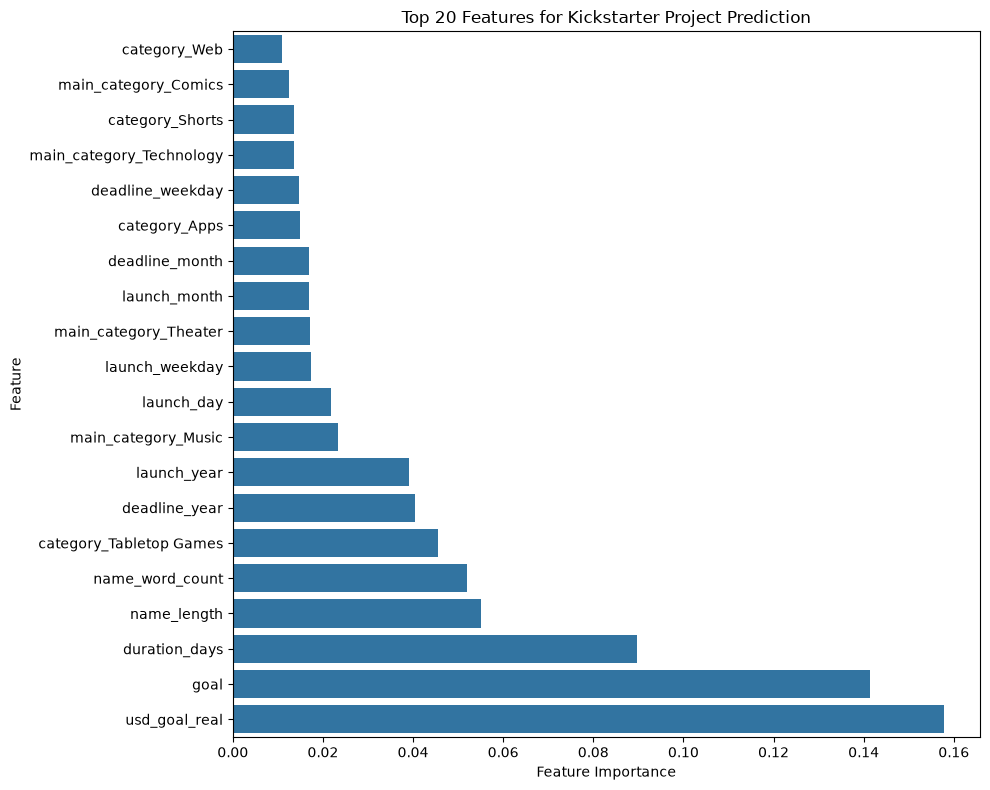

In [101]:
# Plot top 20 feature importances

plt.figure(figsize=(10, 8))

top_features = feature_importance.head(20).sort_values(
    by="Importance"
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Features for Kickstarter Project Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../results/plots/top_20_feature_importance.png",
    dpi=300
)

plt.show()

In [102]:
%pip install joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
# Save the trained Random Forest model

import joblib

joblib.dump(
    rf_model,
    "../results/random_forest_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


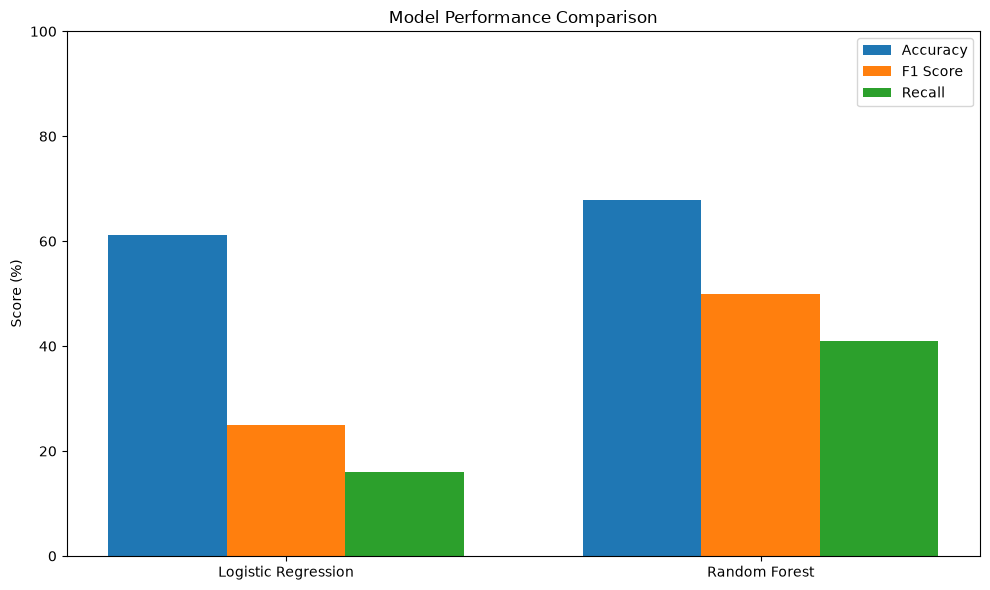

In [104]:
# Compare model performance

import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
accuracies = [accuracy * 100, rf_accuracy * 100]
f1_scores = [0.25, 0.50]
recalls = [0.16, 0.41]

x = range(len(models))

plt.figure(figsize=(10, 6))

plt.bar(x, accuracies, width=0.25, label="Accuracy")
plt.bar([i + 0.25 for i in x], [f * 100 for f in f1_scores],
        width=0.25, label="F1 Score")
plt.bar([i + 0.50 for i in x], [r * 100 for r in recalls],
        width=0.25, label="Recall")

plt.xticks([i + 0.25 for i in x], models)
plt.ylabel("Score (%)")
plt.title("Model Performance Comparison")
plt.legend()
plt.ylim(0, 100)

plt.tight_layout()

plt.savefig("../results/plots/model_performance_comparison.png", dpi=300)

plt.show()

In [105]:
# Final project results summary

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Successful Project F1 Score",
        "Successful Project Recall"
    ],
    "Logistic Regression": [
        round(accuracy * 100, 2),
        25.00,
        16.00
    ],
    "Random Forest": [
        round(rf_accuracy * 100, 2),
        50.00,
        41.00
    ]
})

print("Final Model Performance Summary:")
display(final_results)

Final Model Performance Summary:


,Metric,Logistic Regression,Random Forest
0,Accuracy,61.22,67.79
1,Successful Project F1 Score,25.00,50.00
2,Successful Project Recall,16.00,41.00


In [106]:
# Save final model results

final_results.to_csv(
    "../results/final_model_results.csv",
    index=False
)

print("Final model results saved successfully!")

Final model results saved successfully!


# Final Conclusion

The analysis was performed to understand the factors associated with Kickstarter project success.

The exploratory analysis examined funding goals, campaign duration, countries, currencies, categories, and their relationship with project outcomes.

Feature engineering was performed using numerical, categorical, date-based, and text-based features. Categorical variables were encoded using one-hot encoding, and the dataset was divided into training and testing sets.

Two classification models were trained and evaluated:

- Logistic Regression achieved an accuracy of 61.22%.
- Random Forest achieved an accuracy of 67.79%.

For successful projects, the Random Forest achieved an F1-score of 0.50 and recall of 0.41, compared with 0.25 and 0.16 for Logistic Regression.

Random Forest feature importance indicated that `usd_goal_real`, `goal`, and `duration_days` were among the most influential features in the model.

Overall, the analysis demonstrates how machine learning can be applied to Kickstarter project data to study and predict project outcomes.